In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import os
import numpy as np

from utils import ensure_project_files

In [3]:
base_url = "https://raw.githubusercontent.com/fdalforno/personalFinance/refs/heads/main/"
file_paths = [
    "data/sp500top20.csv",
    "data/sp500cap.csv",
]
ensure_project_files(base_url,file_paths) 

Locale / Jupyter


In [2]:
df_dettaglio = pd.read_csv("./data/sp500top20.csv")
df_totale = pd.read_csv("./data/sp500cap.csv")

In [3]:
n_companies = 10

In [4]:
df_top = (
    df_dettaglio
    .sort_values(['Year', 'Rank'], ascending=[True, True])
    .groupby('Year')
    .head(n_companies)
)


In [5]:
df_totale["Percentage"] = df_totale["Top20 Market Cap"] / df_totale["SP500 Market Cap"]

In [6]:
if "Year" in df_totale.columns:
    df_totale = df_totale.set_index("Year")

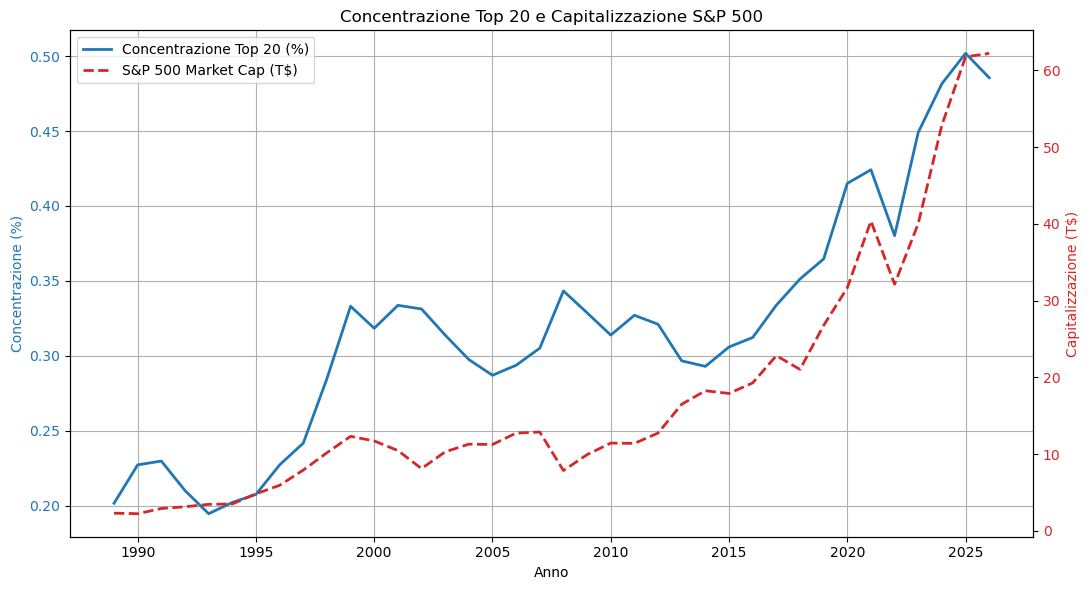

In [7]:

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(
    df_totale.index,
    df_totale["Percentage"],
    color="tab:blue",
    linewidth=2,
    label="Concentrazione Top 20 (%)"
)
ax1.set_xlabel("Anno")
ax1.set_ylabel("Concentrazione (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    df_totale.index,
    df_totale["SP500 Market Cap"] / 1e12,
    color="tab:red",
    linewidth=2,
    linestyle="--",
    label="S&P 500 Market Cap (T$)"
)
ax2.set_ylabel("Capitalizzazione (T$)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Titolo
plt.title("Concentrazione Top 20 e Capitalizzazione S&P 500")

# Legenda combinata
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()


In [8]:
rank_matrix = df_top.pivot(
    index="Company",
    columns="Year",
    values="Rank"
)


In [9]:
reference_year = 1989

rank_matrix = rank_matrix.loc[
    rank_matrix[reference_year].sort_values(na_position="last").index
]


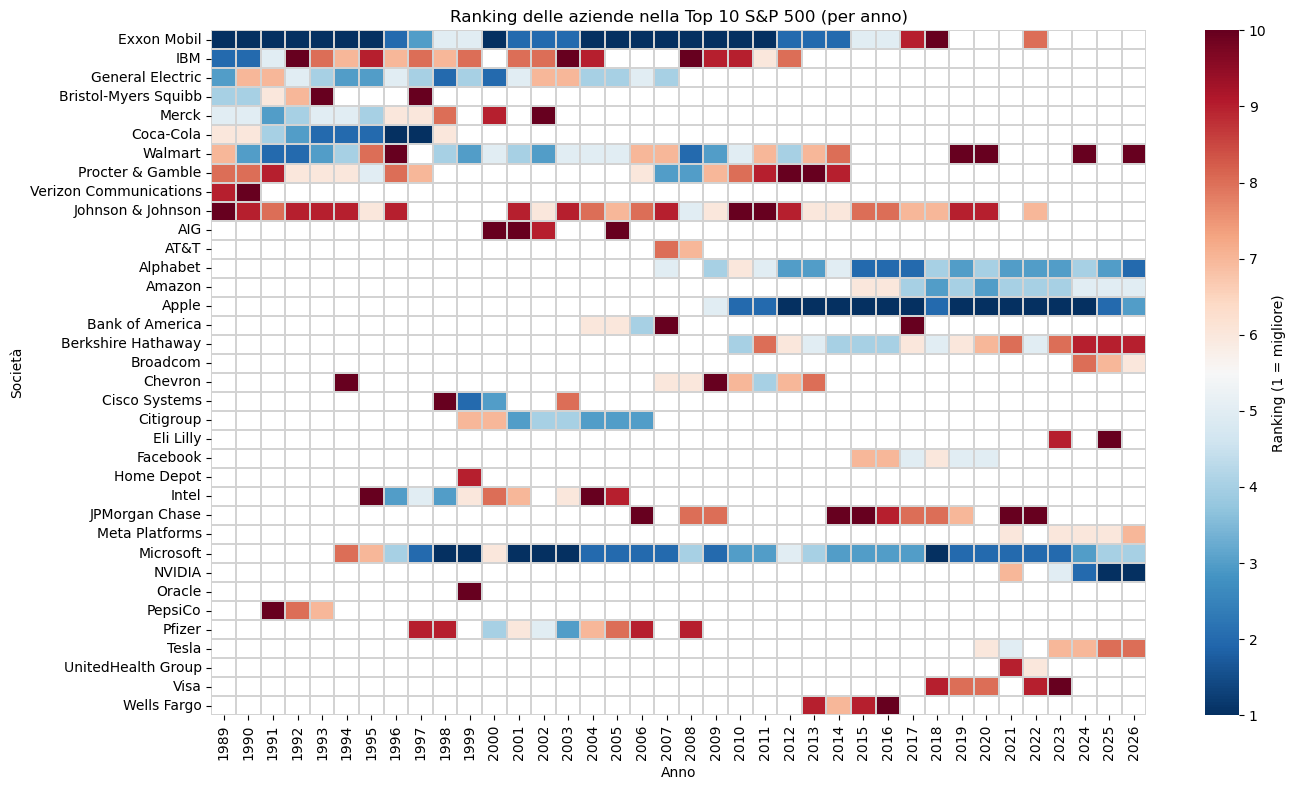

In [10]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    rank_matrix,
    cmap="RdBu_r",
    vmin=1,
    vmax=10,
    linewidths=0.2,
    linecolor="lightgray",
    cbar_kws={"label": "Ranking (1 = migliore)"},
    mask=rank_matrix.isna()
)

plt.title("Ranking delle aziende nella Top 10 S&P 500 (per anno)")
plt.xlabel("Anno")
plt.ylabel("Società")

plt.tight_layout()
plt.show()



In [11]:
start_year = 1989
n_years = 10

# Calcola il ricambio per ogni finestra di n_years
def calculate_turnover(df, start_year, n_years):
    results = []
    
    for year in df['Year'].unique():
        if year >= start_year + n_years:
            year_start = year - n_years
            
            # Aziende nel periodo iniziale
            companies_start = set(df[df['Year'] == year_start]['Company'].unique())
            # Aziende nel periodo finale
            companies_end = set(df[df['Year'] == year]['Company'].unique())
            
            # Calcola le metriche
            new_companies = len(companies_end - companies_start)
            removed_companies = len(companies_start - companies_end)
            staying_companies = len(companies_start & companies_end)
            turnover_rate = (new_companies + removed_companies) / len(companies_start) if companies_start else 0
            
            results.append({
                'Period_Start_Year': year_start,
                'Period_End_Year': year,
                'New_Companies': new_companies,
                'Removed_Companies': removed_companies,
                'Staying_Companies': staying_companies,
                'Turnover_Rate': turnover_rate
            })
    
    return pd.DataFrame(results)

df_turnover = calculate_turnover(df_top, start_year, n_years)
df_turnover

,Period_Start_Year,Period_End_Year,New_Companies,Removed_Companies,Staying_Companies,Turnover_Rate
0,1989,1999,6,6,4,1.2
1,1990,2000,6,6,4,1.2
2,1991,2001,5,5,5,1.0
3,1992,2002,4,4,6,0.8
4,1993,2003,5,5,5,1.0
5,1994,2004,4,4,6,0.8
6,1995,2005,4,4,6,0.8
7,1996,2006,4,4,6,0.8
8,1997,2007,6,6,4,1.2
9,1998,2008,5,5,5,1.0


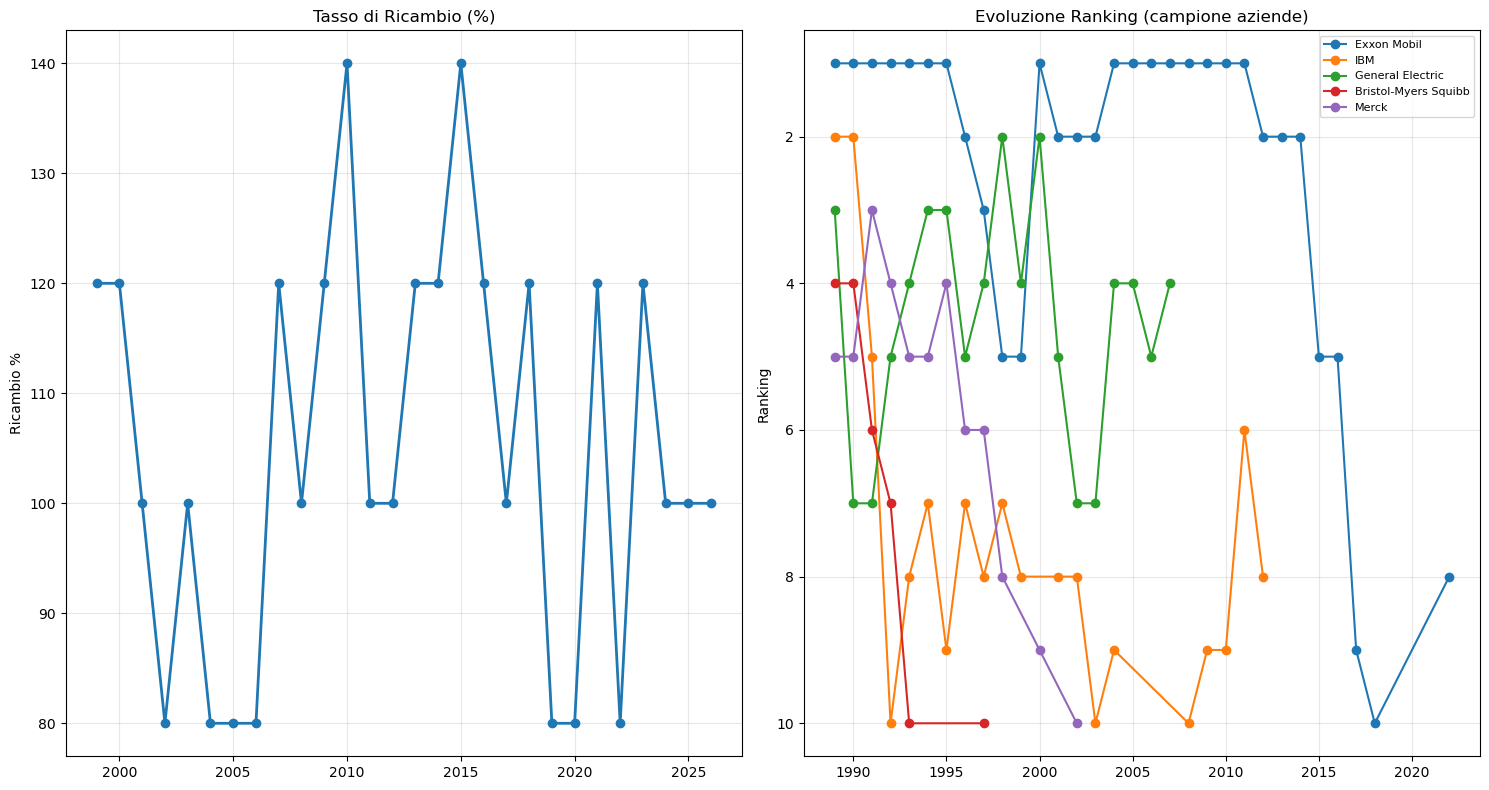

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# 1. Tassi di ricambio nel tempo
axes[0].plot(df_turnover['Period_End_Year'], df_turnover['Turnover_Rate'] * 100, 
                marker='o', linewidth=2, color='tab:blue')
axes[0].set_title('Tasso di Ricambio (%)')
axes[0].set_ylabel('Ricambio %')
axes[0].grid(True, alpha=0.3)

# 2. Ranking evolution per aziende (line plot)
for company in df_top['Company'].unique()[:5]:  # Top 5 aziende
    company_data = df_top[df_top['Company'] == company].sort_values('Year')
    axes[1].plot(company_data['Year'], company_data['Rank'], marker='o', label=company)
axes[1].invert_yaxis()
axes[1].set_title('Evoluzione Ranking (campione aziende)')
axes[1].set_ylabel('Ranking')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)




plt.tight_layout()
plt.show()

In [13]:
years = sorted(df_top.loc[df_top['Year'] >= start_year, 'Year'].unique())
years_to_plot = years[::n_years]

# aggiunge l’ultimo anno se non è già presente
if years[-1] not in years_to_plot:
    years_to_plot.append(years[-1])



df_subsample = df_top[df_top['Year'].isin(years_to_plot)]

In [14]:
year_colors = {
    1989: "#4C72B0",  # muted blue
    1999: "#55A868",  # muted green
    2009: "#C7A252",  # muted ochre
    2019: "#8172B2",  # muted purple
    2026: "#CC8963",  # muted copper
}

In [15]:
df_joined = df_subsample.merge(
    df_totale,
    left_on="Year",
    right_index=True,
    how="left"
)


df_joined["Weight SP500 pct"] = (
    df_joined["Market Cap"] / df_joined["SP500 Market Cap"] * 100
)


In [16]:
first_year_map = (
    df_joined
    .groupby("Company")["Year"]
    .min()
    .to_dict()
)


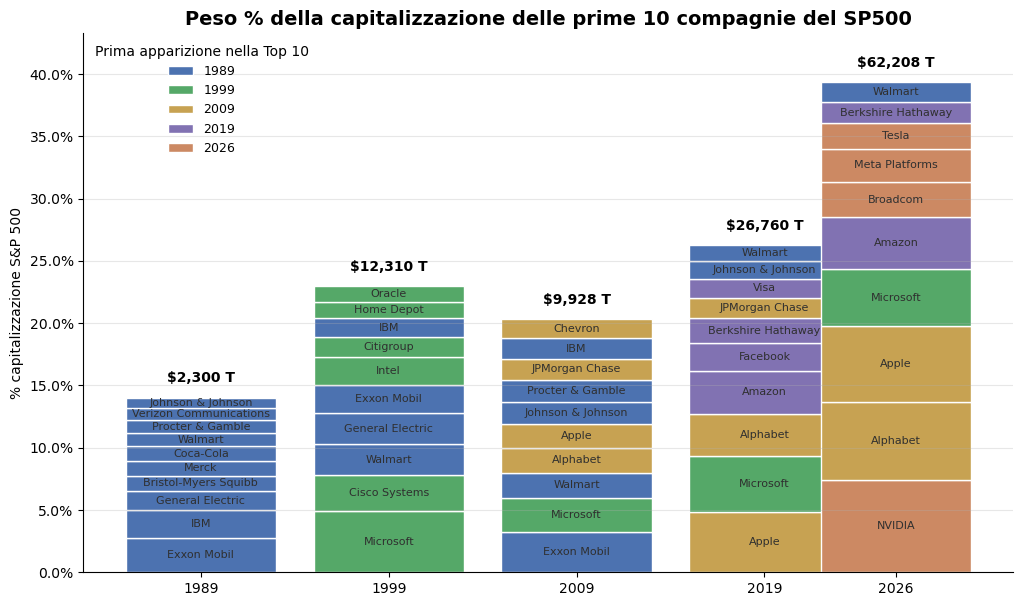

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

bottoms = {year: 0 for year in years_to_plot}
capitalizations = {year: 0 for year in years_to_plot}

for year in years_to_plot:
    df_year = df_joined[df_joined['Year'] == year]

    mcap = df_year['SP500 Market Cap'].iloc[0]
    capitalizations[year] = mcap

    for _, row in df_year.iterrows():
        weight = row["Weight SP500 pct"]
        company = row["Company"]
        color_map = year_colors[first_year_map[company]]

        ax.bar(
            year,
            weight,
            bottom=bottoms[year],
            width=8,
            edgecolor="white",
            color=color_map
        )

        ax.text(
            year,
            bottoms[year] + weight / 2,
            company,
            ha="center",
            va="center",
            fontsize=8,
            color="#2F2F2F"
        )

        bottoms[year] += weight


for year in years_to_plot:
    ax.text(
        year,
        bottoms[year] + 1,                     # leggermente sopra lo stack
        f"${capitalizations[year] / 1e9:,.0f} T",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


legend_elements = [
    Patch(
        facecolor=color,
        edgecolor="white",
        label=f"{year}"
    )
    for year, color in sorted(year_colors.items())
]


ax.legend(
    handles=legend_elements,
    title="Prima apparizione nella Top 10",
    frameon=False,
    loc="upper left",
    fontsize=9,
    title_fontsize=10
)



ax.set_title(
    "Peso % della capitalizzazione delle prime 10 compagnie nell'indice SP500",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("% capitalizzazione S&P 500")


ax.set_xticks(years_to_plot)
ax.set_xticklabels(years_to_plot)

ax.set_ylim(0, max(bottoms.values()) * 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# cartella di output
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

# percorso completo del file
output_path = os.path.join(output_dir, "sp500_top10_weight.png")


plt.savefig(
    output_path,
    dpi=300,                # qualità stampa
    bbox_inches="tight",    # evita tagli a titoli/legenda
    facecolor="white"       # sfondo pulito
)


plt.show()